In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)


# Read the data

In [4]:
data = pd.read_csv(r"C:\Users\adity\Downloads\german_credit_data.csv")

# EDA (Exploratory Data Analysis)

In [5]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [6]:
data.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [7]:
data.shape

(1000, 10)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [16]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,522.0,493.522989,291.131014,1.0,233.5,502.5,736.75,999.0
Age,522.0,34.888889,11.787918,19.0,26.0,31.5,41.00,75.0
Job,522.0,1.875479,0.682811,0.0,2.0,2.0,2.00,3.0
Credit amount,522.0,3278.745211,2929.155177,276.0,1297.5,2326.5,3971.25,18424.0
Duration,522.0,21.339080,12.474079,6.0,12.0,18.0,26.75,72.0


# Data Preprocessing

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data = data.dropna()

In [11]:
data.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

 # Data Imputation

In [12]:
data['Saving accounts'] = data['Saving accounts'].fillna('no_account')

In [63]:
# data.drop('Checking accounts' , axis=1, inplace = True)

In [14]:
data['Checking account'] = data['Checking account'].fillna('no_account')

In [15]:
data.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

# Univariate Analysis

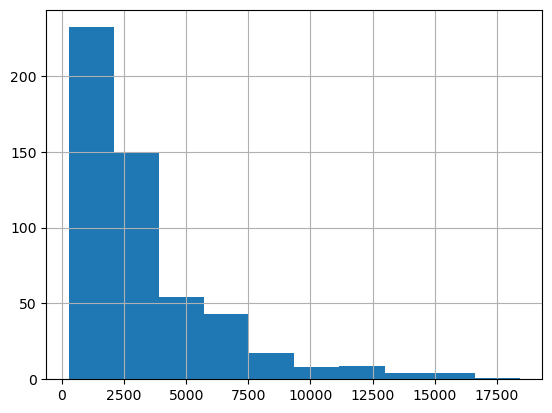

In [17]:
data['Credit amount'].hist()
plt.show()

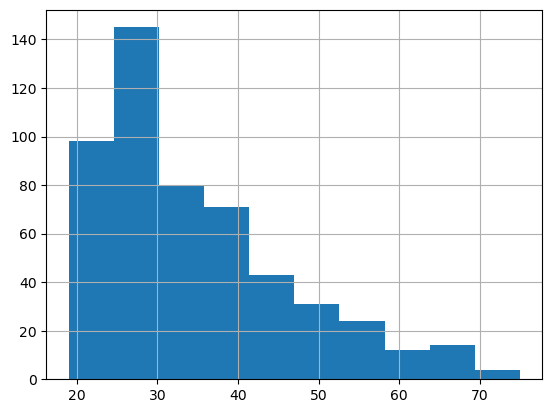

In [18]:
data['Age'].hist()
plt.show()

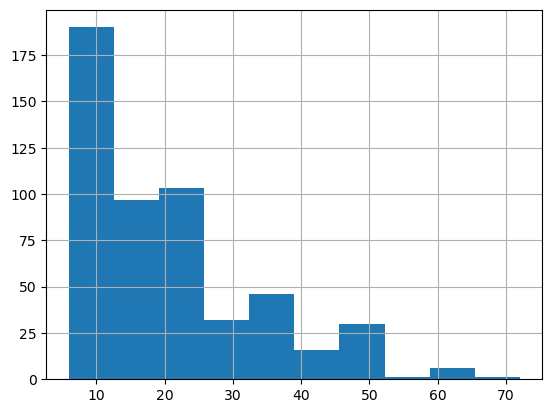

In [19]:
data['Duration'].hist()
plt.show()

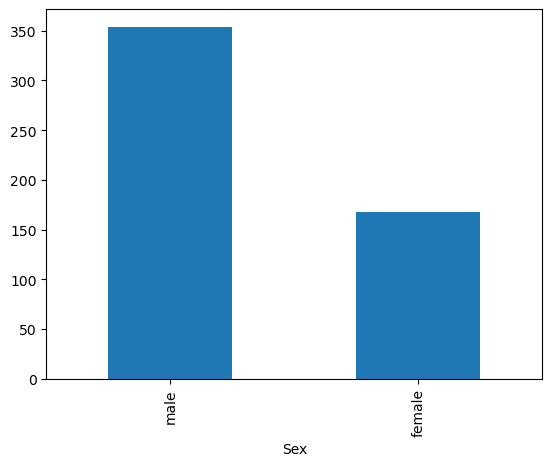

In [20]:
data['Sex'].value_counts().plot(kind='bar')
plt.show()

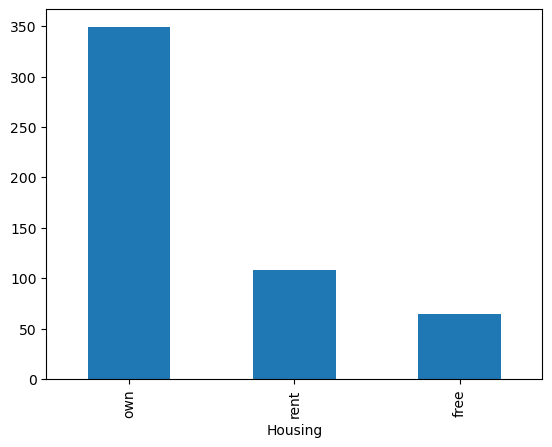

In [21]:
data['Housing'].value_counts().plot(kind='bar')
plt.show()

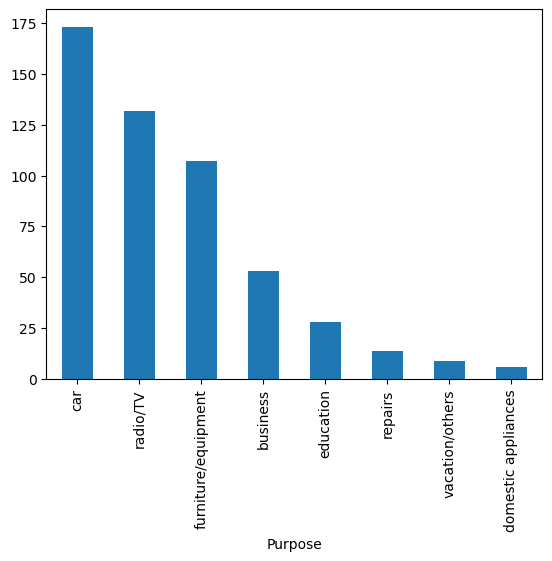

In [22]:
data['Purpose'].value_counts().plot(kind='bar')
plt.show()

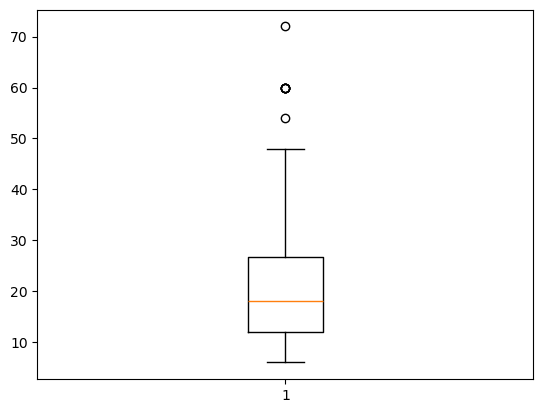

In [23]:
plt.boxplot(data['Duration'])
plt.show()

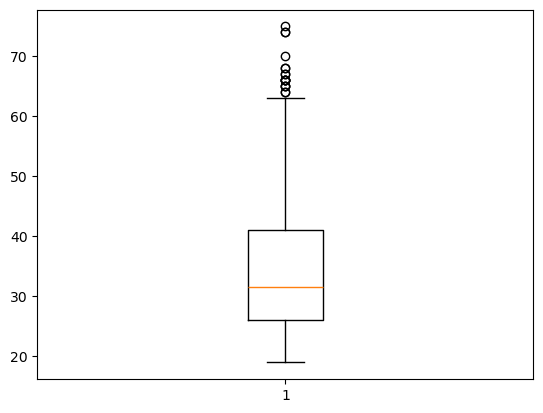

In [24]:
plt.boxplot(data['Age'])
plt.show()

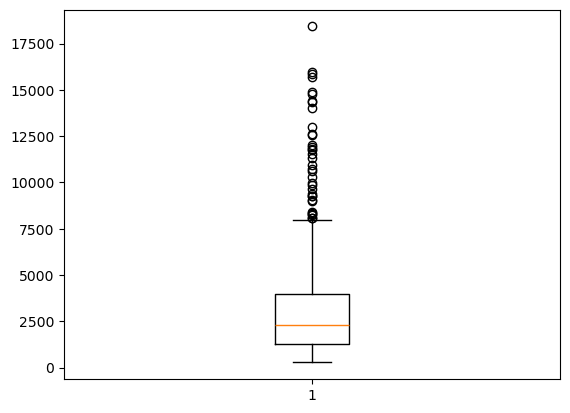

In [25]:
plt.boxplot(data['Credit amount'])
plt.show()

# remove outliers using IQR

In [26]:
Q1 = data['Credit amount'].quantile(0.25)
Q3 = data['Credit amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Credit amount'] >= lower) & (data['Credit amount'] <= upper)]

In [27]:
Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Age' ]>= lower) & (data['Age'] <= upper)]

In [28]:
Q1 = data['Duration'].quantile(0.25)
Q3 = data['Duration'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Duration'] >= lower) & (data['Duration'] <= upper)]

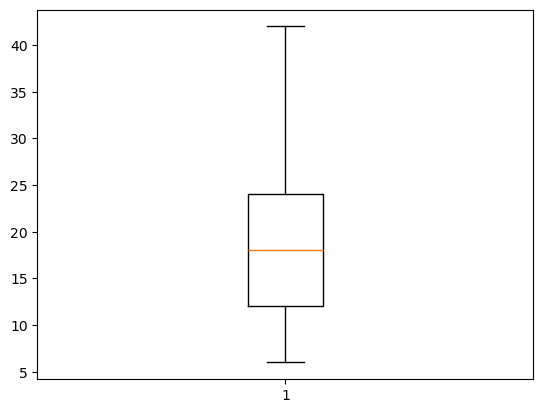

In [29]:
plt.boxplot(data['Duration'])
plt.show()

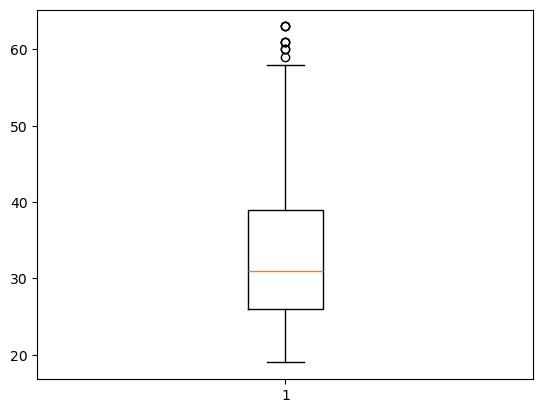

In [30]:
plt.boxplot(data['Age'])
plt.show()

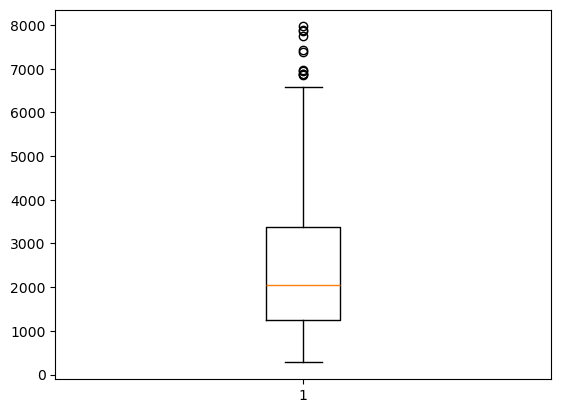

In [31]:
plt.boxplot(data['Credit amount'])
plt.show()

# Bivariate analysis

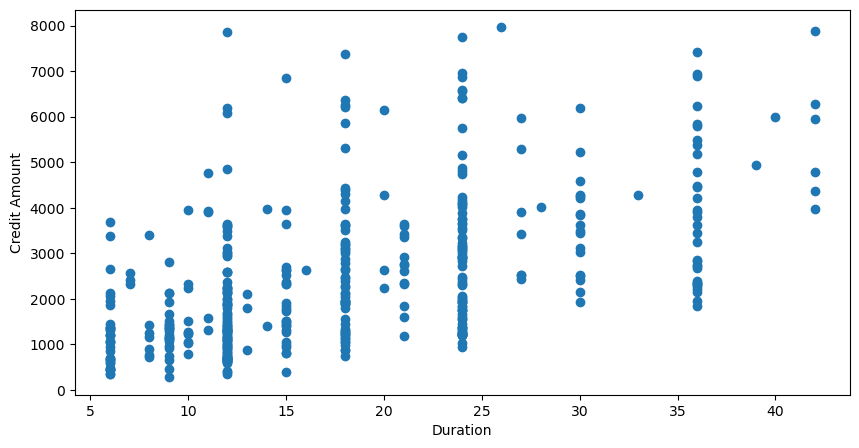

In [46]:
plt.figure(figsize=(10,5))
plt.scatter(data['Duration'], data['Credit amount'])
plt.xlabel("Duration")
plt.ylabel("Credit Amount")
plt.show()

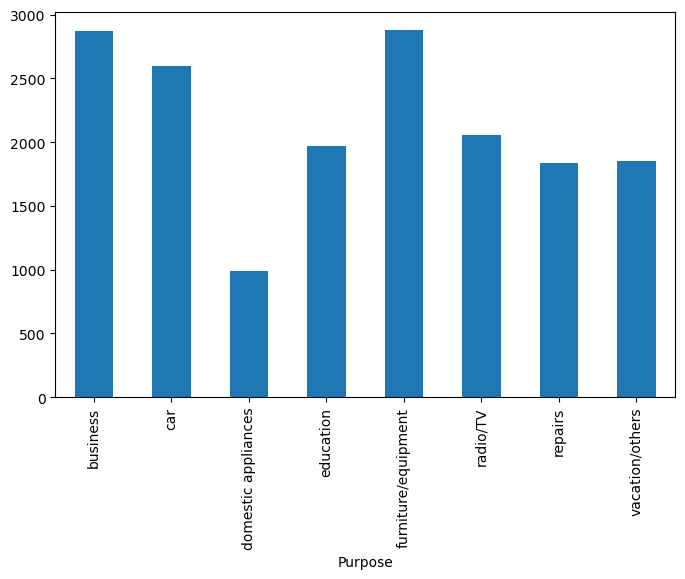

In [49]:
plt.figure(figsize=(8,5))
data.groupby('Purpose')['Credit amount'].mean().plot(kind='bar')
plt.show()

<Figure size 1000x300 with 0 Axes>

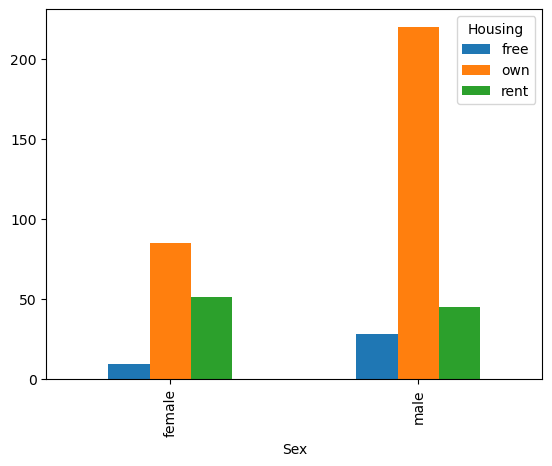

In [54]:
plt.figure(figsize=(10,3))
pd.crosstab(data['Sex'], data['Housing']).plot(kind='bar')
plt.show()

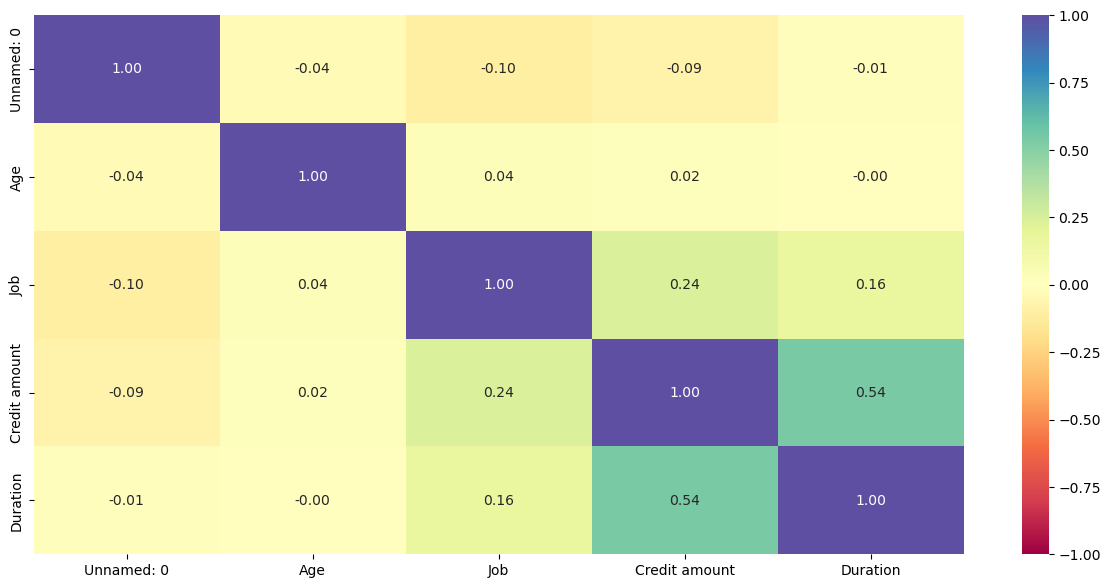

In [36]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

<Figure size 1000x500 with 0 Axes>

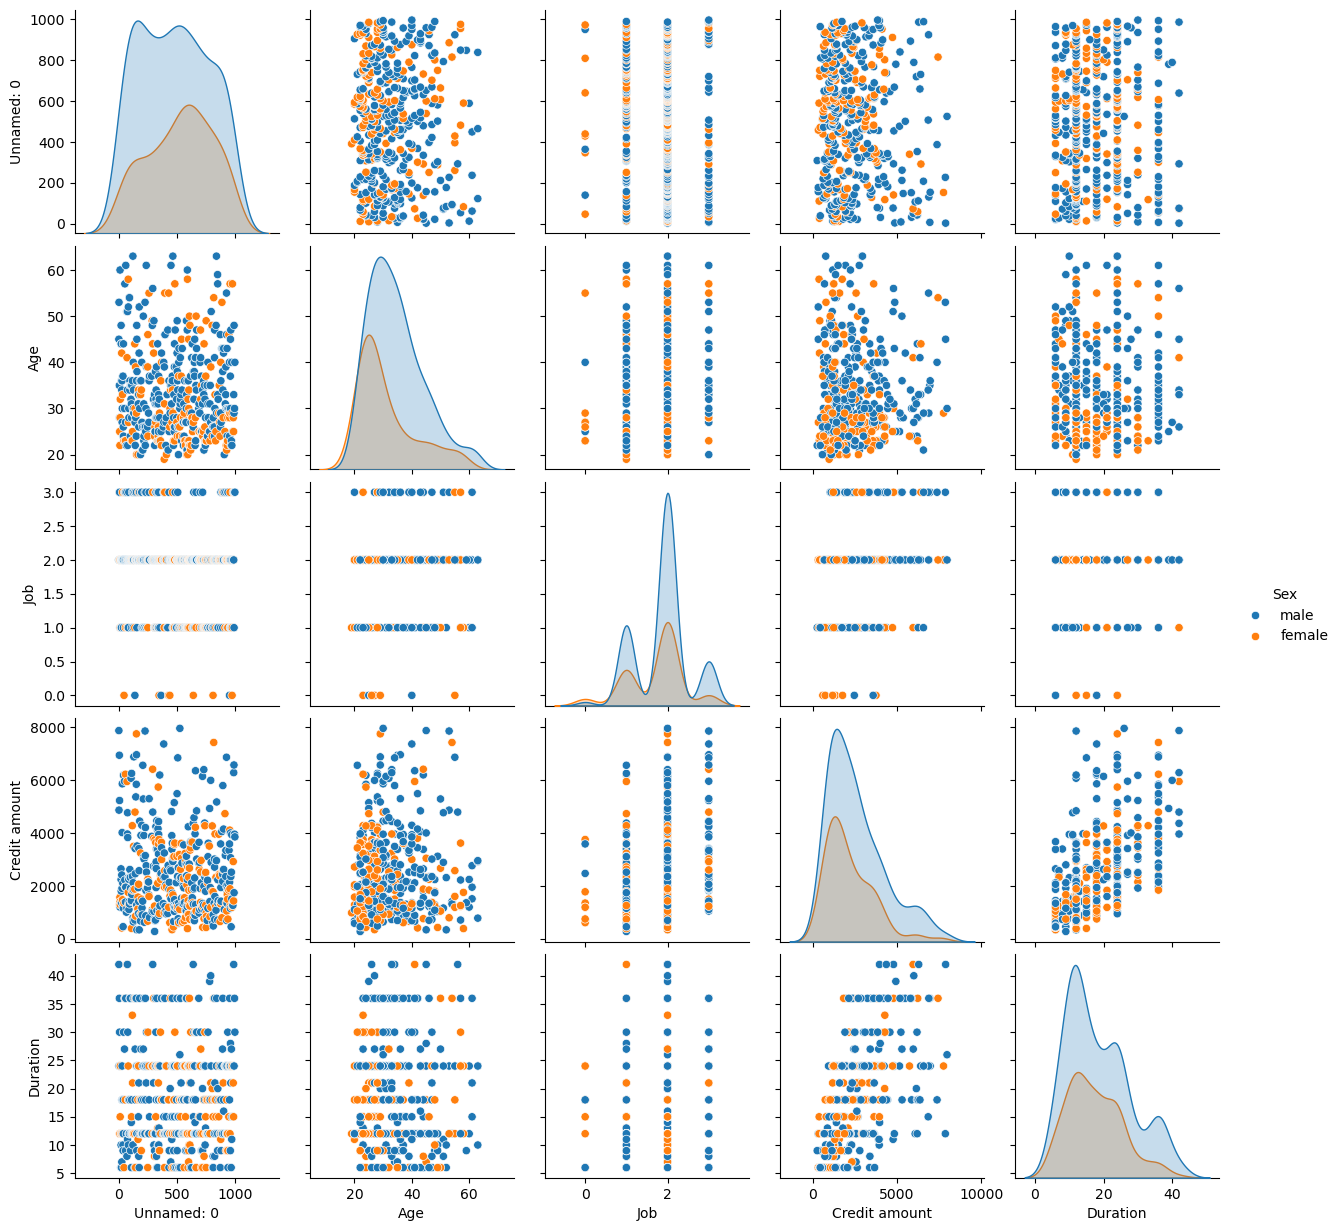

In [75]:
plt.figure(figsize=(10,5))
sns.pairplot(data,hue='Sex')
plt.show()

# Model Training

In [76]:

# X and y
X = data.drop('Job', axis=1)
y = data['Job']

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Split
train_test_split(X, y, test_size=0.2, random_state=42)
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=5000)

# Fit
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [73]:
y_pred = model.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6136363636363636
